# NODE / UDE - Remaining Useful Life (NASA C-MAPSS)

Este notebook implementa:

- Preprocesamiento de datos
- Construcción y desarrollo de modelo de probabilidad
- NODE (Neural ODE)
- UDE (Universal Differential Equation)

In [1]:
using Pkg
Pkg.activate(".")



#solo la primera vez:
#Pkg.instantiate()

  Activating project at `c:\Users\usuario\Desktop\TP-DegradacionDeMotores\mi_entorno`


## Todas los paquetes que utilizaremos.

In [2]:
ENV["GKSwstype"] = "100"

using CSV
using DataFrames
using Statistics
using Plots

using Lux
using ComponentArrays
using Random
Random.seed!(42)

using OrdinaryDiffEq
using SciMLSensitivity

using Optimization
using OptimizationOptimisers
using Zygote
using DataInterpolations

#batches
using MLUtils
using LinearAlgebra

## Carga de datos

In [17]:
dataset_path = joinpath(pwd(), "..", "CMaps", "train_FD001.txt")

train_df = CSV.read(
    dataset_path,
    DataFrame;
    delim=' ',
    ignorerepeated=true,
    header=false
)


#agregamos los nombres de la columnas ya que el dataset original venian sin ellos
rename!(
    train_df,
    vcat(
        ["unit", "cycle", "setting1", "setting2", "setting3"],
        ["s$i" for i in 1:21]
    )
)

first(train_df, 5)

Row,unit,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64
1,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419
2,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236
3,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
4,1,4,0.0007,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
5,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044


## Normalización de sensores y settings

In [18]:
#Normalizamos los datos de los sensores y settings para mejorar entrenamiento de redes neuronales.


sensor_cols = ["s$i" for i in 1:21]
setting_cols = ["setting1", "setting2", "setting3"]
    
for col in sensor_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end
    
for col in setting_cols
    μ = mean(train_df[!, col])
    σ_col = std(train_df[!, col])
    train_df[!, col] = (train_df[!, col] .- μ) ./ σ_col
end

## Modelado de la falla mediante análisis de supervivencia

Inicialmente, la probabilidad de falla se construía a partir del RUL (Remaining Useful Life) utilizando una transformación sigmoidal:

$$
p_{\text{fail}} = \sigma(k(\text{threshold} - RUL))
$$

Sin embargo, esta construcción introduce supuestos arbitrarios, ya que tanto la forma funcional como los parámetros utilizados no provienen directamente de los datos observados.

Para evitar este problema, reformulamos el problema como uno de **supervivencia discreta**.

### Variable objetivo

Para cada instante temporal \(t\) de una trayectoria, definimos la variable objetivo:

$$
y_t =
\begin{cases}
1 & \text{si el motor falla en el ciclo t}\\
0 & \text{si el motor continúa funcionando}
\end{cases}
$$

Dado que en el dataset de entrenamiento cada trayectoria finaliza en la falla, la última observación de cada motor recibe la etiqueta 1 y todas las observaciones anteriores reciben la etiqueta 0.

### Modelo

Se mantiene la estructura dinámica basada en Neural Ordinary Differential Equations (NODEs). El estado latente \(z(t)\) evoluciona según

$$
\frac{dz}{dt}=f_\theta(z(t),x(t)),
$$

donde \(x(t)\) representa las mediciones de sensores y condiciones operativas.

A partir del estado latente se obtiene una probabilidad mediante una capa de salida sigmoidal:

$$
h_t = \sigma(g_\theta(z_t)).
$$

Esta cantidad se interpreta como la probabilidad de que el motor falle en el próximo ciclo, condicionada a haber sobrevivido hasta el instante actual.

### Entrenamiento

El entrenamiento se realiza mediante máxima verosimilitud para supervivencia discreta. Para una trayectoria que falla en el ciclo \(T\), la probabilidad observada es

$$
P(T)=\left(\prod_{t=1}^{T-1}(1-h_t)\right)h_T.
$$

Equivalentemente, se minimiza la log-verosimilitud negativa:

$$
\mathcal{L}
=
-\sum_{t=1}^{T-1}\log(1-h_t)
-\log(h_T).
$$

Esta formulación permite obtener probabilidades de falla directamente a partir de los datos observados, sin necesidad de construir etiquetas probabilísticas artificiales a partir del RUL.

In [19]:
train_df.event = zeros(Int, nrow(train_df))

for g in groupby(train_df, :unit)
    idx = parentindices(g)[1][end]
    train_df.event[idx] = 1
end



Verificamos:

In [20]:
combine(groupby(train_df, :unit), :event => sum) 
#deberia dar 1 por cada motor

Row,unit,event_sum
,Int64,Int64
1,1,1
2,2,1
3,3,1
4,4,1
5,5,1
6,6,1
7,7,1
8,8,1
9,9,1


## Ejemplo de la nueva columna

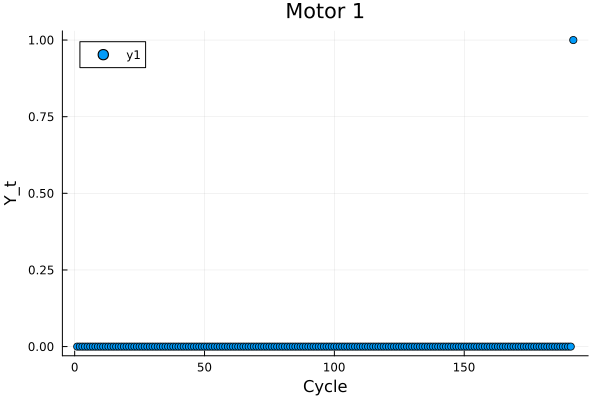

In [21]:
motor1 = filter(row -> row.unit == 1, train_df)
    
plt = scatter(
    motor1.cycle,
    motor1.event,
    xlabel="Cycle",
    ylabel="Y_t",
    title="Motor 1"
)
    
plt

## Trayectorias por motor

In [22]:
#agrupamos por unidad
grouped = groupby(train_df, :unit)
    
trajectories = []
    
for g in grouped
    X = Matrix(g[:, vcat(setting_cols, sensor_cols)])
    y = g.event
    t = g.cycle
    
    push!(trajectories, (X=X, y=y, t=t))
end

## NODE

$$
\frac{dz}{dt} =  NN(z,t)
$$

El primer modelo que vamos a probar es una NODE sin utilizar información de los sensores. Luego aplicamos sigmoide como habíamos comentado antes

In [23]:
#elegimos una trayectoria
traj = trajectories[1]

print(trajectories)

t = Float64.(traj.t)
y = Float64.(traj.y)
    
u0 = [-10.0] #Para el baseline ponemos cond inicial que haga dar una proba chica. Despues lo podemos ir cambiando
    
#generador de numeros aleatorios, sirve para inicializar los pesos de la red
rng = Random.default_rng()

#estructura de la red
nn = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#p: parametros entrenables de la red, st: estados internos
p_node, st_node = Lux.setup(rng, nn)
#esto es para que funcione bien la optimizacion
p_node = ComponentArray(p_node)

Any[(X = [-0.31597202195452145 -1.3729199290729734 NaN 0.9999757643323645 -1.7216836648226865 -0.13425192213570927 -0.925913523696359 -0.9999757643323643 0.14167989491882235 1.1211133982073023 -0.516325892386186 -0.8627924043441415 0.9999757643323643 -0.2664601377187745 0.33425373913469153 -1.0588645739680291 -0.26906451920303553 -0.603801065881639 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.3484600620382499 1.1943981001535333; 0.8727007771683792 -1.0316953503320596 NaN 0.9999757643323645 -1.0617539738121262 0.2115233673416215 -0.6437102649230355 -0.9999757643323643 0.14167989491882235 0.4319197071333588 -0.7980736570341316 -0.9587943771663178 0.9999757643323643 -0.1915782821843463 1.174870847738156 -0.3636371846989997 -0.6428291567796645 -0.27584512524895916 -0.9999757643323645 -0.7816908404632746 NaN NaN 1.0165032941737064 1.2368919830975704; -1.9618266668939224 1.015652122113423 NaN 0.9999757643323645 -0.6617965853206986 -0.4131555754405577 -0.5259404010255218 -0.9999757643323

Excessive output truncated after 524297 bytes.

NaN NaN 1.2931339340607997 -0.09612264925562572; -1.1388993444242221 1.015652122113423 NaN 0.9999757643323645 1.2779967488623394 -0.43762080818661137 0.8639662002555846 -0.9999757643323643 0.14167989491882235 0.612691822824845 0.4697912838848265 -0.908982032777455 0.9999757643323643 0.819326767530262 -0.31654660300994597 0.748726638126389 -1.168615876961072 -1.84096819152017 -0.9999757643323645 -0.13601426883344866 NaN NaN -0.8092589290812037 -0.016677563751543337; -0.4074083911178215 0.33320296463159566 NaN 0.9999757643323645 1.15800953231482 -0.5778881425972175 0.26400651624934107 -0.9999757643323643 0.14167989491882235 0.7030778806706522 0.4697912838848265 -0.8867928975497062 0.9999757643323643 -0.3787829210204036 -0.5741550717754418 0.47063568242004183 -1.3337433115145398 -0.04387628919174641 -0.9999757643323645 0.5096623027963773 NaN NaN -0.8645850570586537 -0.5894212034320633; -0.17881746820957142 1.356876700854337 NaN 0.9999757643323645 0.8780393603709116 0.4349724930887953 0.65

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.18582273 0.073365726; -1.3326262 1.9626849; … ; -1.2206342 0.22496898; 1.2360227 0.50070494], bias = Float32[0.45274794, -0.109943174, 0.2535509, 0.33633876, -0.58940434, -0.5645052, -0.6811371, -0.25305128, 0.11489113, 0.6639945, -0.4025346, -0.6888659, -0.4826754, 0.3613354, 0.48929778, -0.21674016]), layer_2 = (weight = Float32[0.3199716 0.046035804 … 0.03958083 -0.19888853], bias = Float32[-0.0893096]))

Definimos la NODE

In [7]:
function node!(du, u, p, t)
    input = [u[1], t]

    du .= nn(input, p, st_node)[1]
end

node! (generic function with 1 method)

In [12]:
#todo el intervalo de tiempo
tspan = (t[1], t[end])
	
#definimos el problema de ode
prob_node = ODEProblem(node!, u0, tspan, p_node)
	
#resolvemos con solver numerico
sol = solve(prob_node, Tsit5(), saveat=t)

#Al no haber entrenado el sistema, no se obtienen buenos resultados por ahora

┌ Warning: Mixed-Precision `matmul_cpu_fallback!` detected and Octavian.jl cannot be used for this set of inputs (C [Matrix{Float64}]: A [Base.ReshapedArray{Float32, 2, SubArray{Float32, 1, Vector{Float32}, Tuple{UnitRange{Int64}}, true}, Tuple{}}] x B [Matrix{Float64}]). Falling back to generic implementation. This may be slow.
└ @ LuxLib.Impl C:\Users\Sebastian\.julia\packages\LuxLib\zPBrt\src\impl\matmul.jl:194


retcode: Success
Interpolation: 1st order linear
t: 192-element Vector{Float64}:
   1.0
   2.0
   3.0
   4.0
   5.0
   6.0
   7.0
   8.0
   9.0
  10.0
  11.0
  12.0
  13.0
   ⋮
 181.0
 182.0
 183.0
 184.0
 185.0
 186.0
 187.0
 188.0
 189.0
 190.0
 191.0
 192.0
u: 192-element Vector{Vector{Float64}}:
 [-10.0]
 [-8.780622759474427]
 [-7.5805077916837496]
 [-6.720907178753919]
 [-6.174018158692469]
 [-5.783400814511278]
 [-5.452365599762099]
 [-5.192293643108463]
 [-5.19810144592661]
 [-5.43733644400067]
 [-5.753428302551949]
 [-6.080326618890222]
 [-6.392108509421911]
 ⋮
 [-72.39145382643432]
 [-72.79646555484896]
 [-73.2014860303423]
 [-73.60651456251976]
 [-74.01155045969172]
 [-74.41659302887358]
 [-74.82164157578565]
 [-75.22669540485325]
 [-75.6317538192067]
 [-76.03681612068124]
 [-76.44188160981709]
 [-76.84694958585948]

### Entrenamiento NODE

In [8]:
#definimos la funcion sigmoide:
σ(x) = 1 / (1 + exp(-x))


#funcion de prediccion
function predict(prob, p, t)

    _prob = remake(prob, p=p)

    sol = solve(
        _prob,
        Tsit5(),
        saveat=t
    )

    z_pred = Array(sol)[1, :]
    h_pred = σ.(z_pred)

    return h_pred
end

#funcion de perdida: verosimilitud de la trayectoria
function loss(prob, p, t, y)

    h = predict(prob, p, t)

    ϵ = 1f-7 #el epsilon es para no evaluar log(0)

    Tfail = findfirst(==(1), y)

    l = -sum(
        y .* log.(h .+ ϵ) .+
        (1 .- y) .* log.(1 .- h .+ ϵ)
    )

    return l
end

loss (generic function with 1 method)

In [13]:
#convertimos la funcion loss en algo digerible por el optimizador. Con AutoZygote() calculamos los gradientes.
optf_node = OptimizationFunction((x, _) -> loss(prob_node,x,t,y), AutoZygote())

#Define el problema de opt. Quiero minimizar optf empezando de parametros iniciales p.
optprob_node = OptimizationProblem(optf_node, p_node)

#Resulve el problema de opt. Con Adam version de descenso por el gradiente y 0.01 el learning rate.
result_node = Optimization.solve(optprob_node, Adam(0.01), maxiters=500)
	
p_trained_node = result_node.u

#prediccion final luego de entrenar:
pred_node = predict(prob_node, p_trained_node, t)

192-element Vector{Float64}:
 4.5397868702434395e-5
 1.572941636784752e-5
 5.322132732914268e-6
 1.5969751812734953e-6
 3.5474498425299597e-7
 6.50830421523749e-8
 1.1326647615183072e-8
 1.9388541165898763e-9
 3.2853603036558196e-10
 5.508299991519877e-11
 ⋮
 1.8642979308672455e-151
 2.900868903816894e-152
 4.513785193770017e-153
 7.023501389088556e-154
 1.0928648494500086e-154
 1.7005102056682017e-155
 2.6460133300368993e-156
 4.1172270059957336e-157
 6.406452313162104e-158

Graficamos la sol obtenida

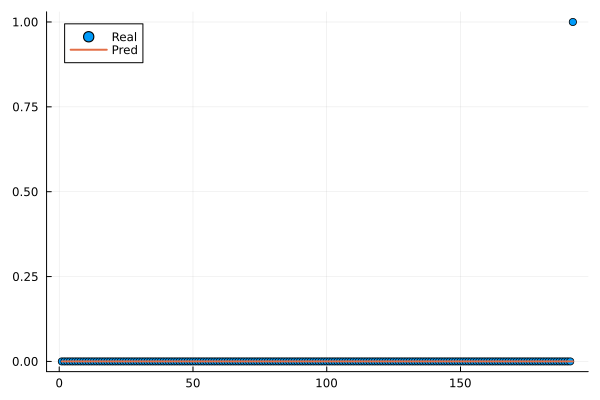

In [14]:
p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_node,
    label = "Pred",
    linewidth = 2
)

p1

## UDE

Ahora además de tener un red neuronal en el sistema, agregamos un término físico a la ecuación diferencial.

$$
\frac{dz}{dt} = -\alpha z + NN(z, t)
$$

In [15]:
#Definimos la red
nn2 = Lux.Chain(
    Lux.Dense(2, 16, tanh),
    Lux.Dense(16, 1)
)

#parametros y estado interno
p_ude, st_ude = Lux.setup(rng, nn2)
p_ude = ComponentArray(p_ude)
    
α = 0.05

#definimos ude
function ude!(dz, z, p, t)

    input = [z[1], t]
    dz .= .-α .* z .+ nn2(input, p, st_ude)[1]

end

#definimos problema ode
prob_ude = ODEProblem(ude!, u0, tspan, p_ude)

#mismo proceso de antes
optf_ude = OptimizationFunction(
(x, _) -> loss(prob_ude,x,t,y),
AutoZygote()
)

optprob_ude = OptimizationProblem(optf_ude, p_ude)

result_ude = Optimization.solve(
    optprob_ude,
    Adam(0.01),
    maxiters=500
)

p_trained_ude = result_ude.u
pred_ude = predict(prob_ude, p_trained_ude, t)

192-element Vector{Float64}:
 4.5397868702434395e-5
 1.9857457265463165e-5
 1.0015235437388616e-5
 5.885035847926051e-6
 4.609551022899267e-6
 4.682053518466153e-6
 4.9441736964792406e-6
 5.2386940211093195e-6
 5.723246997615993e-6
 6.951122881420266e-6
 ⋮
 0.003781314753718315
 0.0037816006993591673
 0.0037818722578954037
 0.003782130645859085
 0.0037823770877325807
 0.003782612815910562
 0.0037828390706656496
 0.003783057100117729
 0.0037832681602071004

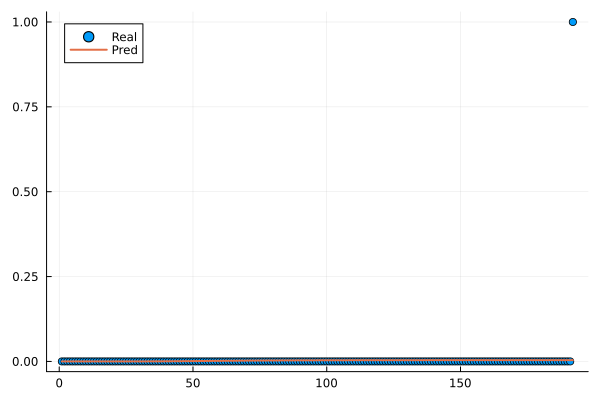

In [16]:
p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude,
    label = "Pred",
    linewidth = 2
)

p1

Por ahora en los dos modelos que tenemos obtenemos un resultado constantemente 0. Veamos si al entrenar con más motores cambiamos esto

## Entrenamiento de UDE con más motores

Hasta ahora veníamos entrenando con una sola trayectoria y evavluando en la misma. Veamos que pasa si entrenamos con más de una trayectoria.

In [24]:
function build_train_trajs(trajectories; n_motors=nothing, shuffle=false, seed=1234)

    total_motors = length(trajectories)

    if n_motors === nothing
        selected_ids = collect(1:total_motors)
    else
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = collect(1:n)
    end


    #esto recontraponele, capaz sirve capaz no, pero como el test te da cualquier motor esto lo hace mas random
    if shuffle
        rng = Random.default_rng()
        Random.seed!(rng, seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    train_trajs = [
        (
            X = trajectories[i].X,
            t = Float64.(trajectories[i].t),
            y = Float64.(trajectories[i].y)
        )
        for i in selected_ids
    ]

    return train_trajs
end



build_train_trajs (generic function with 1 method)

##  UDE: término físico + red neuronal + sensores 

A partir de ahora vamos a incorporar la información de sensores al sistema.

$$
\frac{dz}{dt} = -\alpha z + NN(z,\tau,S(t))
$$

De esta parte en adelante vamos a realizar diferentes entrenamientos donde utilizamos una red neuronal y sus pesos. Para evitar utilizar pesos ya entrenados y hacerlo más limpio definimos la siguiente función:

In [25]:
function init_model(input_dim)

    nn = Lux.Chain(
        Lux.Dense(input_dim, 8, tanh),
        Lux.Dense(8, 1)
    )

    rng = MersenneTwister(1234)

    p, st = Lux.setup(rng, nn)

    return nn, ComponentArray(p), st
end

init_model (generic function with 1 method)

Modificamos la función para elegir trayectorias, agregando el parámetro sensors. Este parámetro nos va a permitir elegir que sensores queremos utilizar. Y además nos devuelve un test set

In [26]:
function build_train_test_trajs_sensors(trajectories;n_motors=nothing,test_ratio=0.2,shuffle=false,sensors=nothing,seed=67)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    # shuffle opcional (solo para definir el orden base)
    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    # elegir subset de motores
    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    # split train/test (20% test, siguientes en la lista)
    n_test = Int(round(test_ratio * length(selected_ids)))
    test_ids = selected_ids[end - n_test + 1:end]
    train_ids = selected_ids[1:end - n_test]

    # default sensors
    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    # helper para construir dataset
    function build(ids)
        trajs = []

        for i in ids

            t = Float64.(trajectories[i].t)
            S = Float64.(trajectories[i].X[:, sensors])

            sensor_interps = [
                LinearInterpolation(S[:, j], t)
                for j in 1:size(S,2)
            ]

            push!(trajs,
                (
                    sensor_interps = sensor_interps,
                    sensors_ids = sensors,
                    t = t,
                    y = Float64.(trajectories[i].y)
                )
            )
        end

        return trajs
    end

    train_trajs = build(train_ids)
    test_trajs  = build(test_ids)

    return train_trajs, test_trajs
end

build_train_test_trajs_sensors (generic function with 1 method)

In [27]:
function ude_sensors!(dz, z, p, τ, S)

    input = [z[1]; τ; S] 

    out, _ = nn2(input, p, st_ude_sensors)

    dz[1] = -α * z[1] + out[1]

end

ude_sensors! (generic function with 1 method)

In [28]:
function predict_traj_sensors(p, traj)

    tvec = traj.t
    y = traj.y

    z0 = [-10.0] #seguimos con eso...

    t0 = tvec[1]
    tf = tvec[end]
    tspan = (t0, tf)

    function f!(du, z, p, t)

        S = [
            interp(clamp(t, t0, tf))
            for interp in traj.sensor_interps
        ]

        τ = (t - t0) / (tf - t0)

        ude_sensors!(du, z, p, τ, S)

    end

    prob = ODEProblem(f!, z0, tspan, p)

    sol = solve(
        prob,
        Tsit5(),
        saveat=tvec,
        abstol=1e-6,
        reltol=1e-6,
        dtmax=1.0
    )

    z_pred = Array(sol)[1, :]

    h_pred = σ.(z_pred)

    return h_pred

end

function loss_many_sensors(p, trajs)

    total_loss = 0f0
    total_points = 0
    pos_weight = 100f0 #le agrego peso en la loss al punto donde falla
    ϵ = 1f-7 #el epsilon es para no evaluar log(0)

    for traj in trajs
        h = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += -sum(pos_weight .* y .* log.(h .+ ϵ) .+ (1 .- y) .* log.(1 .- h .+ ϵ))
        total_points += length(y)
    end

    return total_loss / total_points

end

loss_many_sensors (generic function with 1 method)

Para la primera prueba tomamos sensores al azar

In [29]:
#Definimos un nuevo callback
callback = function (state, loss)

    global iter += 1

    if iter % 10 == 0
        println("Iteración: $iter / $maxiters | loss = $loss")

    end

    if loss < best_loss - 1e-6

        global best_loss = loss
        global best_params = deepcopy(state.u)

        global counter = 0

    else

        global counter += 1

    end

    if counter >= patience

        println("Early stopping activado")

        return true
    end

    return false
end

#58 (generic function with 1 method)

## Batches

In [30]:
train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=60,
    sensors = [6,7]
)
n_sensors = length(train_trajs[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05

0.05

In [34]:
using MLUtils

In [56]:
using LinearAlgebra

# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 100
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors(
                p,
                batch
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

    norm(
    ComponentVector(p_current) -
    ComponentVector(p0)
    )

end

p_trained_ude_sensors = best_params

epoch=1 | batch_loss=1.226751 | train_loss=1.201768 | best=1.201768
epoch=2 | batch_loss=1.186823 | train_loss=1.166709 | best=1.166709
epoch=3 | batch_loss=1.15456 | train_loss=1.135084 | best=1.135084
epoch=4 | batch_loss=1.123923 | train_loss=1.106525 | best=1.106525
epoch=5 | batch_loss=1.097002 | train_loss=1.080737 | best=1.080737
epoch=6 | batch_loss=1.07182 | train_loss=1.05699 | best=1.05699
epoch=7 | batch_loss=1.048007 | train_loss=1.035053 | best=1.035053
epoch=8 | batch_loss=1.026871 | train_loss=1.014469 | best=1.014469
epoch=9 | batch_loss=1.006353 | train_loss=0.994981 | best=0.994981
epoch=10 | batch_loss=0.9872 | train_loss=0.976373 | best=0.976373
epoch=11 | batch_loss=0.972085 | train_loss=0.958377 | best=0.958377
epoch=12 | batch_loss=0.952729 | train_loss=0.94096 | best=0.94096
epoch=13 | batch_loss=0.934599 | train_loss=0.924013 | best=0.924013
epoch=14 | batch_loss=0.917237 | train_loss=0.907437 | best=0.907437
epoch=15 | batch_loss=0.902861 | train_loss=0.89109

ComponentVector{Float32}(layer_1 = (weight = Float32[-1.0360866 -0.009435052 0.5245951 -0.8260776; -1.4948615 0.62068003 0.8463334 -0.8364698; … ; 0.9147897 -1.5377744 0.0053318157 -0.93488735; 0.8230755 -0.6719622 -0.54669964 -0.8092199], bias = Float32[0.25359446, 0.49785352, -0.7021537, 0.09208452, -0.13359235, 0.52910405, -0.06295379, 0.28961977]), layer_2 = (weight = Float32[-0.3232587 -0.43900388 … 0.2939627 -0.023981689], bias = Float32[-0.0031627482]))

In [53]:
using LinearAlgebra

norm(
    ComponentVector(p_current) -
    ComponentVector(p0)
)

0.11547526f0

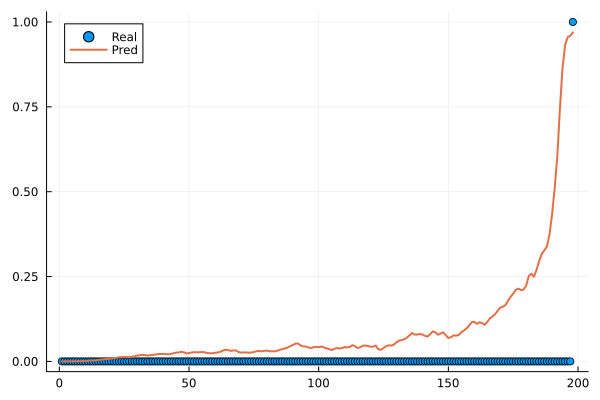

In [57]:
traj_plot = test_trajs[2]
t = traj_plot.t
y = traj_plot.y

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude_sensors,
    label = "Pred",
    linewidth = 2
)

p1

## Hasta aca

Le agregue peso en la loss al punto que falla y empieza a subir la curva. Habria que ver como se puede perfeccionar esto

### Que hice hasta aca:

+ NODE Y UDE sin sensores

+ UDE con sensores y peso en la loss

### Cosas que faltan de lo que teniamos antes:

+ probar los mejores sensores

+ probar distintos modelos

+ hacer un entrenamiento grande

### Cosas a considerar para esta nueva forma de plantear el problema

+ desbalanceo de clases

## Selección de Sensores

En el paso anterior incorporamos los sensores al sistema. Como tenemos muchos sensores, utilizarlos todos puede hacer que obtengamos un modelo muy pesado o también puede ser que repitamos información. Por lo tanto, vamos a llevar a cabo un proceso de **selección de sensores**.

Antes de eso vamos a generar la columna **RUL**(Remaining Useful Life) en nuestro data frame, que la vamos a utilzar en este proceso.

In [40]:
#Construimos el cilo de falla. En el train la falla se da en el último ciclo observado.
fail_cycles = combine(
    groupby(train_df, :unit),
    :cycle => maximum => :T_fail
)

#Obtenemos un df de la siguiente forma:
#unit    T_fail
#1       192

#Ahora mergeamos con el dataset original
train_df = leftjoin(train_df, fail_cycles, on=:unit)

#RUL = T_falla - Ciclo actual
train_df.RUL = train_df.T_fail .- train_df.cycle

20631-element Vector{Int64}:
 191
 190
 189
 188
 187
 186
 185
 184
 183
 182
   ⋮
   8
   7
   6
   5
   4
   3
   2
   1
   0

### 1. Estudiamos varianza de los sensores

In [41]:
variances = DataFrame(
    sensor = sensor_cols,
    variance = [
        var(train_df[!, col])
        for col in sensor_cols
    ]
)

sort!(variances, :variance, rev=true)

variances

Row,sensor,variance
,String,Float64
1,s18,NaN
2,s19,NaN
3,s6,1.0
4,s2,1.0
5,s17,1.0
6,s4,1.0
7,s8,1.0
8,s9,1.0
9,s11,1.0


Recordemos que al principio del trabajo normalizamos los datos de los sensores utilizando la transformación:

$$
\frac{x - \mu}{\sigma}
$$

Por lo tanto, observamos que:

- Dos sensores presentan $Var = NaN$. Esto ocurre debido a que $\sigma = 0$, es decir, el sensor toma un valor constante para todo instante de tiempo y, por lo tanto, no aporta información útil al modelo.

- Cuatro sensores presentan una varianza muy pequeña. En consecuencia, son sensores casi constantes y decidimos excluirlos del análisis.

- Los sensores restantes presentan $Var = 1$, lo cual es esperable luego del proceso de normalización. Estos sensores son los que superan el primer filtro de selección.

In [42]:
#Definimos los sensores válidos hasta el momento:

valid_sensors = []

for col in sensor_cols

    σ_col = std(train_df[!, col])

    if !isnan(σ_col) && σ_col > 1e-8
        push!(valid_sensors, col)
    end
end

println(valid_sensors)

### 2. Correlación con RUL

La idea es identificar sensores cuyo comportamiento esté fuertemente asociado al proceso de degradación del motor.

Utilizamos el coeficiente de correlación de Pearson:

$$
\rho_{X,Y} = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
$$

Valores cercanos a:

- $1$ indican correlación positiva fuerte
- $-1$ indican correlación negativa fuerte
- $0$ indican ausencia de correlación lineal

In [43]:
correlations = DataFrame(
    sensor = valid_sensors,
    correlation = [
        cor(train_df[!, col], train_df.RUL)
        for col in valid_sensors
    ]
)

correlations.abs_corr = abs.(correlations.correlation)

sort!(correlations, :abs_corr, rev=true)

correlations

Row,sensor,correlation,abs_corr
,Any,Float64,Float64
1,s11,-0.696228,0.696228
2,s4,-0.678948,0.678948
3,s12,0.671983,0.671983
4,s7,0.657223,0.657223
5,s15,-0.642667,0.642667
6,s21,0.635662,0.635662
7,s20,0.629428,0.629428
8,s2,-0.606484,0.606484
9,s17,-0.606154,0.606154


### 3. Correlación entre sensores

Hasta ahora miramos la correlación entre los sensores y RUL. Si nos quedamos con los que maximicen esta cantidad puede pasar que seleccionemos sensores que estén muy correlacionados entre ellos. Entonces estudiaremos tambíen la correlación entre sensores:

In [44]:
sensor_corr = cor(Matrix(train_df[:, valid_sensors]))

sensor_corr_df = DataFrame(
    sensor_corr,
    Symbol.(valid_sensors)
)

sensor_corr_df

Row,s2,s3,s4,s6,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1.0,0.60261,0.714949,0.132242,-0.702136,0.662325,0.273764,0.74002,-0.724578,0.661792,0.179752,0.675975,0.629886,-0.661841,-0.66805
2,0.60261,1.0,0.678413,0.116039,-0.664595,0.602481,0.322964,0.6959,-0.680307,0.600963,0.237137,0.639921,0.600017,-0.625941,-0.633901
3,0.714949,0.678413,1.0,0.15048,-0.79313,0.746852,0.297429,0.830136,-0.815591,0.745158,0.190748,0.758459,0.703499,-0.748067,-0.745193
4,0.132242,0.116039,0.15048,1.0,-0.15572,0.152161,0.0193472,0.160014,-0.155884,0.158276,-0.00211233,0.149042,0.13081,-0.141419,-0.137419
5,-0.702136,-0.664595,-0.79313,-0.15572,1.0,-0.767132,-0.217835,-0.822805,0.812713,-0.764611,-0.110053,-0.747051,-0.692893,0.736163,0.737447
6,0.662325,0.602481,0.746852,0.152161,-0.767132,1.0,-0.0320911,0.782213,-0.78654,0.826084,-0.144787,0.700949,0.627785,-0.68703,-0.68884
7,0.273764,0.322964,0.297429,0.0193472,-0.217835,-0.0320911,1.0,0.274591,-0.210238,-0.0347625,0.963157,0.293753,0.33711,-0.28528,-0.292795
8,0.74002,0.6959,0.830136,0.160014,-0.822805,0.782213,0.274591,1.0,-0.846884,0.780761,0.163408,0.780913,0.722296,-0.77151,-0.772554
9,-0.724578,-0.680307,-0.815591,-0.155884,0.812713,-0.78654,-0.210238,-0.846884,1.0,-0.788441,-0.0981405,-0.766052,-0.703485,0.751943,0.756263


Ahora realizaremos una selección greedy sin redundancia:
+ Ordenamos por correlación con RUL
+ Descartamos sensores muy correlacionados entre sí (si la correlación es mayor a 0.8 no lo utilizamos)

In [45]:
threshold = 0.8

selected_sensors = String[]

for sensor in correlations.sensor

    keep = true

    for selected in selected_sensors

        c = cor(
            train_df[:, sensor],
            train_df[:, selected]
        )

        if abs(c) > threshold
            keep = false
            break
        end
    end

    if keep
        push!(selected_sensors, sensor)
    end

    # nos quedamos con 5
    if length(selected_sensors) >= 5
        break
    end
end

Buscamos los índices de los sensores elegidos

In [46]:
feature_cols = vcat(setting_cols, sensor_cols)

sensor_indices = [
    findfirst(==(s), feature_cols)
    for s in selected_sensors
]

5-element Vector{Int64}:
 14
 18
 24
 23
  5

In [47]:
for (s, idx) in zip(selected_sensors, sensor_indices)
    display( s)
    display( idx)
    
end
#no puedo ver el output

sensors_df = DataFrame(
    sensor = selected_sensors,
    index = sensor_indices
)

"s11"

14

"s15"

18

"s21"

...

"s20"

23

"s2"

5

Row,sensor,index
,String,Int64
1,s11,14
2,s15,18
3,s21,24
4,s20,23
5,s2,5


Luego de esto damos por finalizada la selección de sensores!

## UDE + mejores sensores

Ahora probamos el mismo modelo de antes pero utilizando los sensores seleccionados en la paso anterior.

In [48]:
train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=10,
    sensors = sensor_indices
)
n_sensors = length(train_trajs[1].sensor_interps)

println("Cantidad de sensores usados: ", n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05

0.05

In [68]:


# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors(
                p,
                batch
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params

epoch=1 | batch_loss=0.547585 | train_loss=0.539733 | best=0.539733
epoch=2 | batch_loss=0.539733 | train_loss=0.533455 | best=0.533455
epoch=3 | batch_loss=0.533455 | train_loss=0.527766 | best=0.527766
epoch=4 | batch_loss=0.527766 | train_loss=0.522414 | best=0.522414
epoch=5 | batch_loss=0.522414 | train_loss=0.517254 | best=0.517254
epoch=6 | batch_loss=0.517254 | train_loss=0.512244 | best=0.512244
epoch=7 | batch_loss=0.512244 | train_loss=0.507346 | best=0.507346
epoch=8 | batch_loss=0.507346 | train_loss=0.502575 | best=0.502575
epoch=9 | batch_loss=0.502575 | train_loss=0.497951 | best=0.497951
epoch=10 | batch_loss=0.497951 | train_loss=0.493467 | best=0.493467
epoch=11 | batch_loss=0.493467 | train_loss=0.489123 | best=0.489123
epoch=12 | batch_loss=0.489123 | train_loss=0.484879 | best=0.484879
epoch=13 | batch_loss=0.484879 | train_loss=0.48072 | best=0.48072
epoch=14 | batch_loss=0.48072 | train_loss=0.476629 | best=0.476629
epoch=15 | batch_loss=0.476629 | train_loss=0.

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.6375674 -0.16825202 … -0.39433748 0.7046666; -1.1243225 0.40968066 … -0.24104896 0.20112576; … ; 0.74970776 -1.0142617 … 0.15556625 -0.48999226; 0.50822806 -0.5768561 … -0.12498506 0.820287], bias = Float32[0.15820843, -0.11937771, 0.40744516, 0.15129104, -0.19560446, -0.028693905, -0.3799048, 0.22885644]), layer_2 = (weight = Float32[0.2672425 -0.09174892 … 0.48747677 -0.1212077], bias = Float32[0.064554706]))

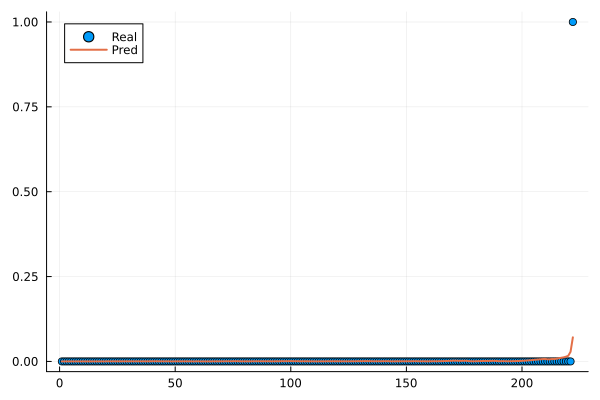

In [36]:
traj_plot = test_trajs[2]
t = traj_plot.t
y = traj_plot.y

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude_sensors,
    label = "Pred",
    linewidth = 2
)

p1

Esto no da mejor que antes... hay que ver la forma de aumentar los 1

## Pesos ajustados (no) arbitramiente:

Vamos a ajustar un poco los pesos

In [36]:

function loss_many_sensors_adj(p, trajs; b = 0.5, c = 1.0)

    total_loss = 0.0
    ϵ = 1f-7 #el epsilon es para no evaluar log(0)
    

    total_points= length(trajs) 
    for traj in trajs

        h = predict_traj_sensors(p, traj)
        h_event = h[end]
        h_survival = h[1:end-1]

        event_loss = -log(h_event + ϵ) #Alpha controla detectar correctamente la falla

        survival_loss = -mean(log.(1 .- h_survival .+ ϵ)) #Beta castiga los falsos positivos antes de la falla

        total_loss += c * event_loss + b * survival_loss

    end

    return total_loss / total_points

end

loss_many_sensors_adj (generic function with 1 method)

penalizar no subir en el evento final

penalizar subir antes de tiempo, en promedio


In [37]:
    train_trajs, test_trajs = build_train_test_trajs_sensors(
        trajectories;
        n_motors=10,
        sensors = sensor_indices
    )
    n_sensors = length(train_trajs[1].sensor_interps)

    println("Cantidad de sensores usados: ", n_sensors)

    input_dim = 2 + n_sensors

    nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

    α = 0.05


UndefVarError: UndefVarError: `sensor_indices` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [71]:
# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors_adj(
                p,
                batch,
                b = 0.5,
                c = 50
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params

epoch=1 | batch_loss=11.626447 | train_loss=0.547996 | best=0.547996
epoch=2 | batch_loss=11.292535 | train_loss=0.548686 | best=0.547996
epoch=3 | batch_loss=10.964188 | train_loss=0.549607 | best=0.547996
epoch=4 | batch_loss=10.641221 | train_loss=0.550747 | best=0.547996
epoch=5 | batch_loss=10.323735 | train_loss=0.55208 | best=0.547996
epoch=6 | batch_loss=10.011331 | train_loss=0.5536 | best=0.547996
epoch=7 | batch_loss=9.704618 | train_loss=0.555312 | best=0.547996
epoch=8 | batch_loss=9.404061 | train_loss=0.557201 | best=0.547996
epoch=9 | batch_loss=9.108927 | train_loss=0.559265 | best=0.547996
epoch=10 | batch_loss=8.819534 | train_loss=0.561504 | best=0.547996
epoch=11 | batch_loss=8.535695 | train_loss=0.563931 | best=0.547996
epoch=12 | batch_loss=8.258372 | train_loss=0.566533 | best=0.547996
epoch=13 | batch_loss=7.986204 | train_loss=0.569317 | best=0.547996
epoch=14 | batch_loss=7.720387 | train_loss=0.572288 | best=0.547996
epoch=15 | batch_loss=7.460516 | train_l

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.7398691 -0.10226696 … -0.31519404 0.60551023; -1.0422168 0.3971915 … -0.37999156 0.34715694; … ; 0.72016954 -0.9670755 … 0.13066444 -0.49140567; 0.6036512 -0.6481301 … -0.20598707 0.8670423], bias = Float32[0.22385167, -0.17047907, 0.34049526, 0.09655093, -0.27311713, -0.07684217, -0.33806184, 0.16003291]), layer_2 = (weight = Float32[0.33025277 0.005187521 … 0.41991732 -0.17684868], bias = Float32[0.12833962]))

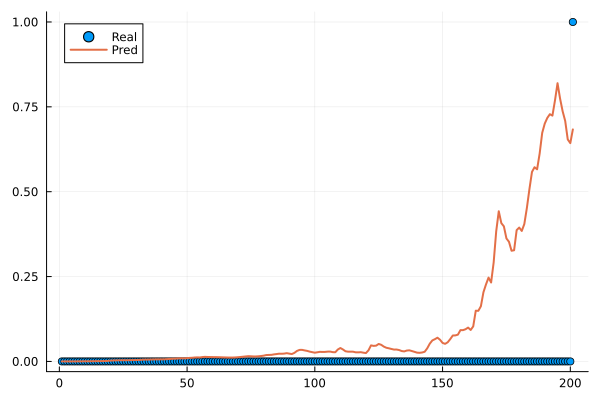

In [72]:
traj_plot = test_trajs[1]
t = traj_plot.t
y = traj_plot.y

pred_ude_sensors = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p1 = plot(
    t,
    y,
    seriestype = :scatter,
    label = "Real",
    markersize = 4
)

plot!(
    p1,
    t,
    pred_ude_sensors,
    label = "Pred",
    linewidth = 2
)
p1

USAR 100!!!! salto rarisimo (el mismo que horizonte, debe ser algun sensor)

# Horizontes

En la formulación original defininimos como positivo únicamente el ciclo exacto de falla:

$$
y_t^{\text{exact}}
=
\begin{cases}
1, & \text{si el motor falla exactamente en el ciclo } t,\\
0, & \text{en otro caso.}
\end{cases}
$$

Sin embargo, esta etiqueta genera un problema muy desbalanceado. Cada trayectoria tiene un único punto positivo y todos los demas negativos.

Por eso, definimos una etiqueta binaria con horizonte de falla \(H\). En este caso, la etiqueta vale 1 si el motor se encuentra a \(H\) ciclos o menos de fallar:

$$
y_t^{(H)}
=
\begin{cases}
1, & \text{si } RUL(t) \leq H,\\
0, & \text{si } RUL(t) > H.
\end{cases}
$$

Equivalente:

$$
y_t^{(H)}
=
\mathbf{1}\{RUL(t) \leq H\}.
$$


In [73]:
function build_train_test_trajs_sensors_horizon(
    trajectories;
    n_motors=nothing,
    test_ratio=0.2,
    shuffle=false,
    sensors=nothing,
    seed=67,
    H=0
)

    total_motors = length(trajectories)

    selected_ids = collect(1:total_motors)

    if shuffle
        rng = MersenneTwister(seed)
        selected_ids = selected_ids[randperm(rng, length(selected_ids))]
    end

    if n_motors !== nothing
        n = min(n_motors, total_motors)
        println("usando $n de $total_motors motores")
        selected_ids = selected_ids[1:n]
    end

    n_test = Int(round(test_ratio * length(selected_ids)))
    test_ids = selected_ids[end - n_test + 1:end]
    train_ids = selected_ids[1:end - n_test]

    if sensors === nothing
        sensors = 4:size(trajectories[1].X, 2)
    end

    function build(ids)
        trajs = []

        for i in ids

            t = Float64.(trajectories[i].t)
            S = Float64.(trajectories[i].X[:, sensors])

            sensor_interps = [
                LinearInterpolation(S[:, j], t)
                for j in 1:size(S, 2)
            ]

            RUL = t[end] .- t
            y_exact = Float64.(RUL .== 0)
            y_horizon = Float64.(RUL .<= H)

            push!(
                trajs,
                (
                    sensor_interps = sensor_interps,
                    sensors_ids = sensors,
                    t = t,
                    y = y_horizon,
                    y_exact = y_exact,
                    RUL = RUL,
                    H = H,
                    unit_id = i
                )
            )
        end

        return trajs
    end

    train_trajs = build(train_ids)
    test_trajs  = build(test_ids)

    return train_trajs, test_trajs
end

build_train_test_trajs_sensors_horizon (generic function with 1 method)

In [74]:
function loss_many_sensors_horizon(p, trajs, pos_weight=100f0)

    total_loss = 0f0
    total_points = 0
    ϵ = 1f-7 #el epsilon es para no evaluar log(0)

    for traj in trajs
        h = predict_traj_sensors(p, traj)
        y = traj.y

        total_loss += -sum(pos_weight .* y .* log.(h .+ ϵ) .+ (1 .- y) .* log.(1 .- h .+ ϵ))
        total_points += length(y)
    end

    return total_loss / total_points

end

function compute_pos_weight(trajs)  #calcula el peso para la clase positiva basado en la proporción de positivos y negativos en las trayectorias

    total_positives = 0
    total_points = 0

    for traj in trajs
        total_positives += sum(traj.y)
        total_points += length(traj.y)
    end

    pos_weight = (total_points - total_positives) / (total_positives + 1e-7)

    return pos_weight
end

compute_pos_weight (generic function with 1 method)

In [75]:
H = 20

train_trajs, test_trajs = build_train_test_trajs_sensors_horizon(
    trajectories;
    n_motors=10,
    test_ratio=0.2,
    shuffle=false,
    sensors=sensor_indices,
    H=H
)

pos_weight = compute_pos_weight(train_trajs)

n_sensors = length(train_trajs[1].sensor_interps)

show("Cantidad de sensores usados: ")
show(n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05


usando 10 de 100 motores
"Cantidad de sensores usados: "5

0.05

In [76]:
# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors(
                p,
                batch
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params

epoch=1 | batch_loss=3.15366 | train_loss=3.087563 | best=3.087563
epoch=2 | batch_loss=3.087563 | train_loss=3.022392 | best=3.022392
epoch=3 | batch_loss=3.022392 | train_loss=2.958014 | best=2.958014
epoch=4 | batch_loss=2.958014 | train_loss=2.894487 | best=2.894487
epoch=5 | batch_loss=2.894487 | train_loss=2.831778 | best=2.831778
epoch=6 | batch_loss=2.831778 | train_loss=2.770047 | best=2.770047
epoch=7 | batch_loss=2.770047 | train_loss=2.709012 | best=2.709012
epoch=8 | batch_loss=2.709012 | train_loss=2.648874 | best=2.648874
epoch=9 | batch_loss=2.648874 | train_loss=2.589645 | best=2.589645
epoch=10 | batch_loss=2.589645 | train_loss=2.531174 | best=2.531174
epoch=11 | batch_loss=2.531174 | train_loss=2.473652 | best=2.473652
epoch=12 | batch_loss=2.473652 | train_loss=2.416908 | best=2.416908
epoch=13 | batch_loss=2.416908 | train_loss=2.361128 | best=2.361128
epoch=14 | batch_loss=2.361128 | train_loss=2.306183 | best=2.306183
epoch=15 | batch_loss=2.306183 | train_loss=

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.66240025 -0.043801513 … -0.38409385 0.67573607; -1.0477152 0.42710194 … -0.36296892 0.32683113; … ; 0.6990831 -1.0540742 … 0.1318709 -0.48149964; 0.5310293 -0.7039552 … -0.14028117 0.7989225], bias = Float32[0.26403522, -0.10796133, 0.30453208, 0.06313072, -0.15558213, -0.104297064, -0.43752855, 0.1257263]), layer_2 = (weight = Float32[0.34838694 -0.05794082 … 0.35884875 -0.21130562], bias = Float32[0.14852737]))

22 minutos

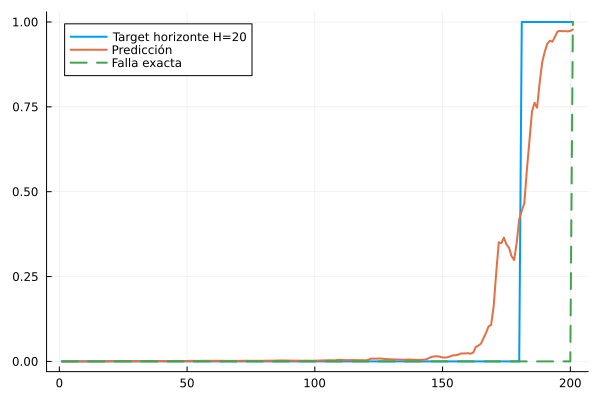

In [77]:
traj_plot = test_trajs[1]

pred = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p = plot(
    traj_plot.t,
    traj_plot.y,
    label="Target horizonte H=$H",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    pred,
    label="Predicción",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    traj_plot.y_exact,
    label="Falla exacta",
    linewidth=2,
    linestyle=:dash
)

p

hay un salto rarisimo entre 150 y 200, pero se ve mejor. Esto es sin usar pesos ajustados por horizonte.

In [ ]:
H = 20

train_trajs, test_trajs = build_train_test_trajs_sensors_horizon(
    trajectories;
    n_motors=10,
    test_ratio=0.2,
    shuffle=false,
    sensors=sensor_indices,
    H=H
)

pos_weight = compute_pos_weight(train_trajs)

n_sensors = length(train_trajs[1].sensor_interps)

show("Cantidad de sensores usados: ")
show(n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05


usando 10 de 100 motores
"Cantidad de sensores usados: "5Iteración: 10 / 1000 | loss = 0.512739155897462
Iteración: 20 / 1000 | loss = 0.46472068099804537
Iteración: 30 / 1000 | loss = 0.4199351746881617
Iteración: 40 / 1000 | loss = 0.37506381154216906
Iteración: 50 / 1000 | loss = 0.33072545669076175
Iteración: 60 / 1000 | loss = 0.2955597539509572
Iteración: 70 / 1000 | loss = 0.28339731647921595
Iteración: 80 / 1000 | loss = 0.2761087119937963
Iteración: 90 / 1000 | loss = 0.2699427084829449
Iteración: 100 / 1000 | loss = 0.26542930483229055
Iteración: 110 / 1000 | loss = 0.26179920209530405
Iteración: 120 / 1000 | loss = 0.2586969043658316
Iteración: 130 / 1000 | loss = 0.25599303096260567
Iteración: 140 / 1000 | loss = 0.2535806061635341
Iteración: 150 / 1000 | loss = 0.25138112634086146
Iteración: 160 / 1000 | loss = 0.24936815566930548
Iteración: 170 / 1000 | loss = 0.24748349159220628
Iteración: 180 / 1000 | loss = 0.24569255740748291
Iteración: 190 / 1000 | loss = 0.244000195

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.2705533 0.15429866 … -0.4952369 0.86800176; -0.14595582 -0.66631746 … -0.49000913 -0.29894632; … ; 0.69411695 -1.1272058 … 0.2985683 -0.59708124; 0.16987766 -0.9740305 … -0.27325934 0.67106545], bias = Float32[-0.24698956, 0.7043648, 0.87035054, 0.7333464, -0.064333215, -0.27558517, -0.46383882, 0.90822375]), layer_2 = (weight = Float32[0.34830767 -0.3934671 … 0.5383785 -0.45890495], bias = Float32[0.013822003]))

In [ ]:
# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors_horizon(
                p,
                batch,
                pos_weight
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params

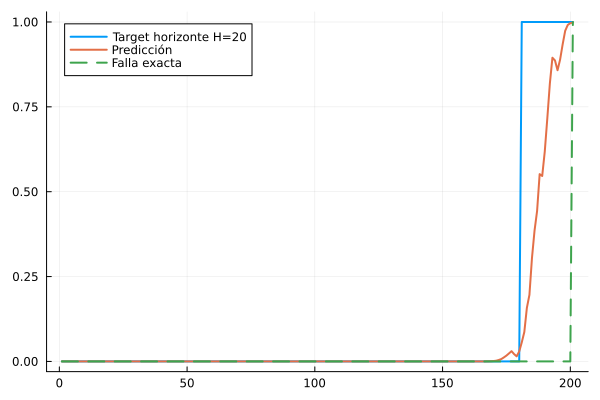

In [51]:
traj_plot = test_trajs[1]

pred = predict_traj_sensors(
    p_trained_ude_sensors,
    traj_plot
)

p = plot(
    traj_plot.t,
    traj_plot.y,
    label="Target horizonte H=$H",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    pred,
    label="Predicción",
    linewidth=2
)

plot!(
    p,
    traj_plot.t,
    traj_plot.y_exact,
    label="Falla exacta",
    linewidth=2,
    linestyle=:dash
)

p

pesos ajustados

### Que hice hasta aca:

+ NODE Y UDE sin sensores

+ UDE con sensores y peso en la loss

+ Seleccion de mejores sensores y UDE

+ Ajuste de pesos

+ Metodo Horizonte

### Cosas que faltan de lo que teniamos antes:

+ probar distintos modelos y parametros entrenables

+ hacer un entrenamiento grande

### Cosas a considerar para esta nueva forma de plantear el problema

+ arreglar salts (horizonte y forma original)

## Realicemos un entrenamiento con muchos motores

In [78]:
H = 20

train_trajs, test_trajs = build_train_test_trajs_sensors_horizon(
    trajectories;
    n_motors=60,
    test_ratio=0.2,
    shuffle=false,
    sensors=sensor_indices,
    H=H
)

pos_weight = compute_pos_weight(train_trajs)

n_sensors = length(train_trajs[1].sensor_interps)

show("Cantidad de sensores usados: ")
show(n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05


usando 60 de 100 motores
"Cantidad de sensores usados: "5

0.05

In [79]:
# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors_horizon(
                p,
                batch,
                pos_weight
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params

epoch=1 | batch_loss=0.619458 | train_loss=3.387604 | best=3.387604
epoch=2 | batch_loss=0.585836 | train_loss=3.207493 | best=3.207493
epoch=3 | batch_loss=0.553819 | train_loss=3.026152 | best=3.026152
epoch=4 | batch_loss=0.519075 | train_loss=2.821492 | best=2.821492
epoch=5 | batch_loss=0.491404 | train_loss=2.626013 | best=2.626013
epoch=6 | batch_loss=0.461416 | train_loss=2.456625 | best=2.456625
epoch=7 | batch_loss=0.432378 | train_loss=2.311272 | best=2.311272
epoch=8 | batch_loss=0.41461 | train_loss=2.267629 | best=2.267629
epoch=9 | batch_loss=0.388398 | train_loss=2.208432 | best=2.208432
epoch=10 | batch_loss=0.371242 | train_loss=2.156688 | best=2.156688
epoch=11 | batch_loss=0.359803 | train_loss=2.098402 | best=2.098402
epoch=12 | batch_loss=0.349577 | train_loss=2.058296 | best=2.058296
epoch=13 | batch_loss=0.343848 | train_loss=1.974111 | best=1.974111
epoch=14 | batch_loss=0.337286 | train_loss=1.89818 | best=1.89818
epoch=15 | batch_loss=0.333225 | train_loss=1.

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.5575068 -0.1206479 … -0.39377755 0.77326804; -0.99703187 0.39678589 … -0.26896632 0.17168407; … ; 0.68791956 -1.1333709 … 0.26466975 -0.63113993; 0.29990312 -0.58426654 … -0.14639848 0.74749184], bias = Float32[0.007336033, 0.03261601, 0.5343422, 0.30985785, -0.045653746, 0.11382253, -0.46923852, 0.4624717]), layer_2 = (weight = Float32[0.31160498 -0.095133886 … 0.5231429 -0.24700765], bias = Float32[0.017074259]))

### Graficamos para todos los motores de Test

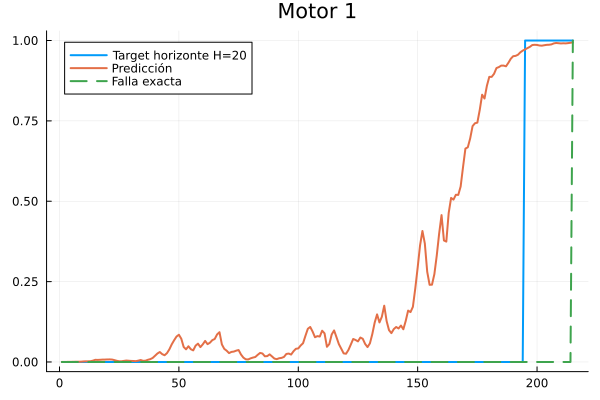

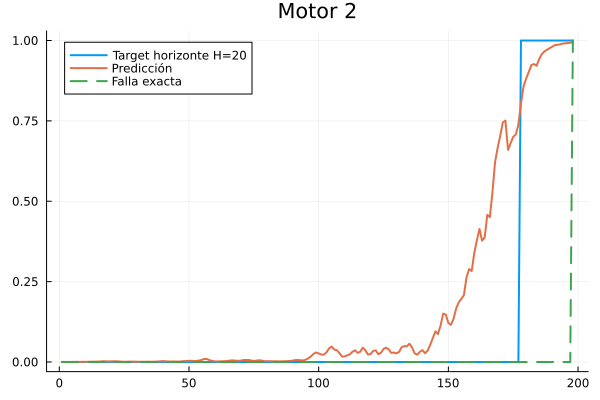

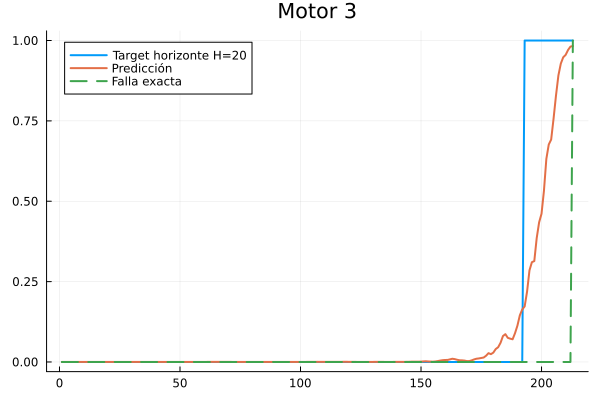

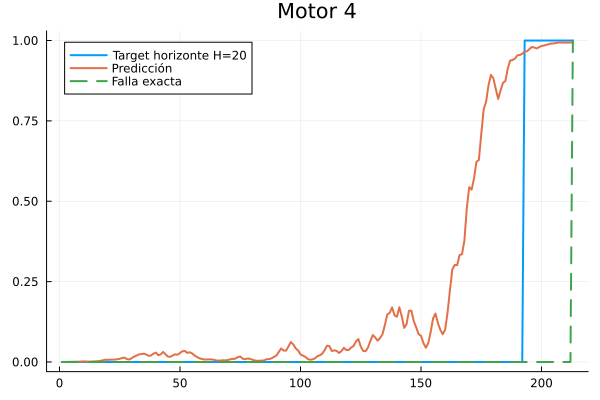

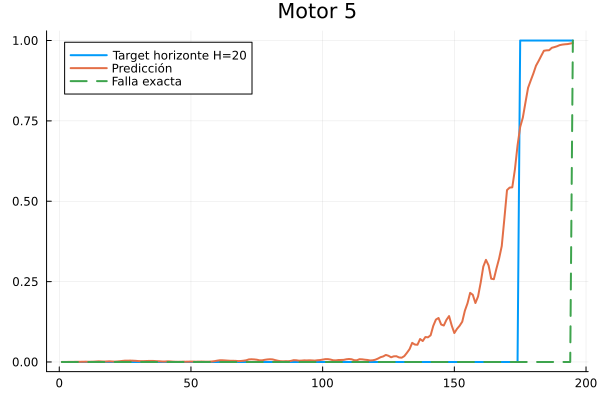

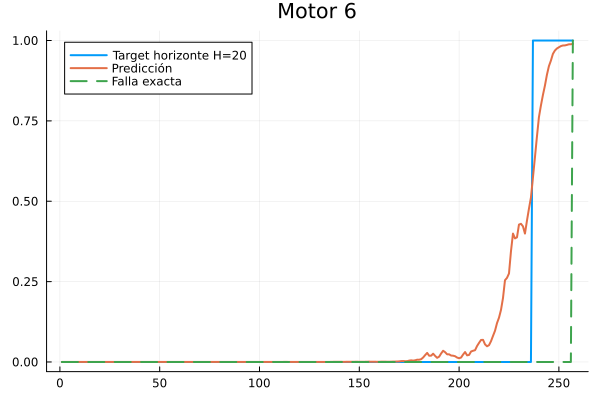

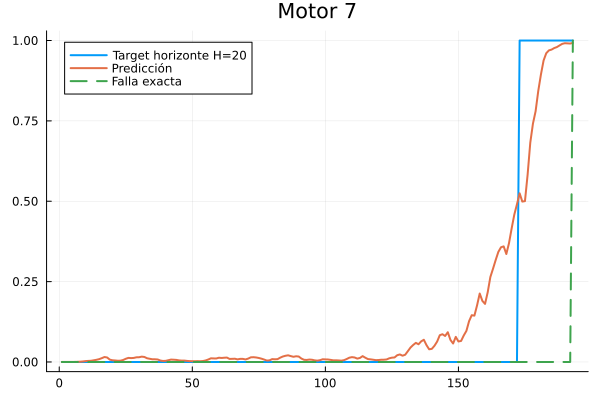

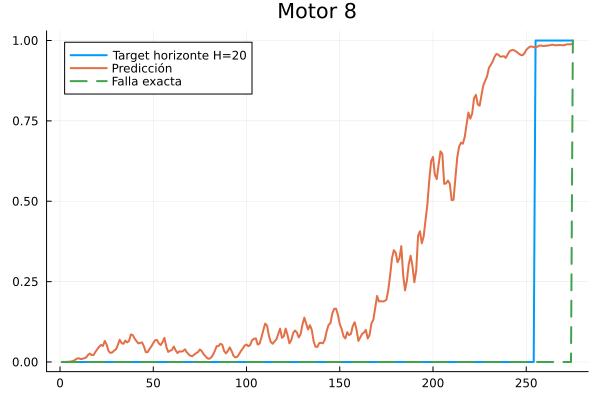

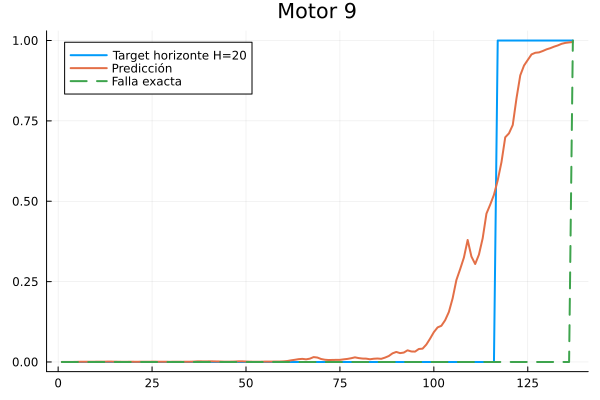

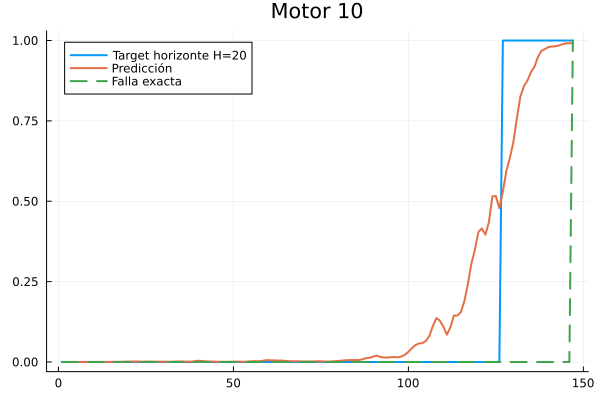

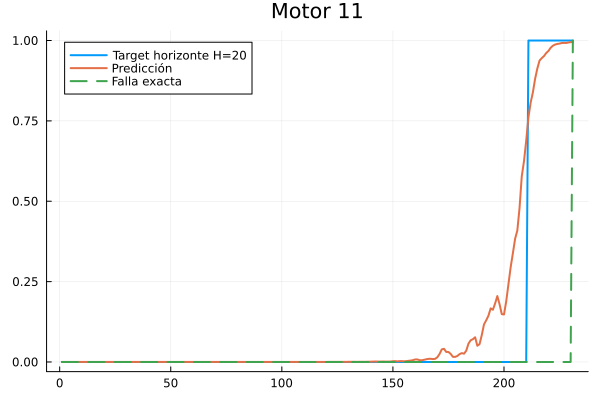

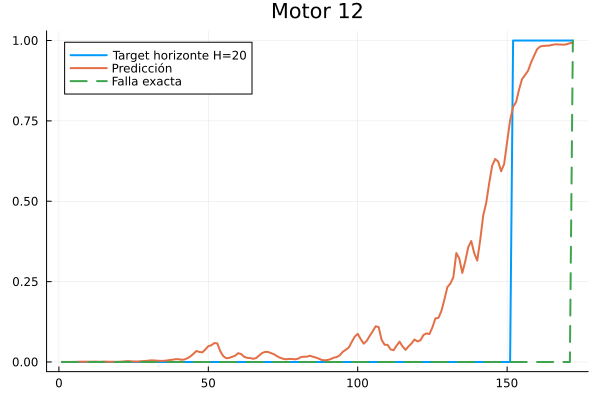

In [80]:
for (i, traj_plot) in enumerate(test_trajs)

    pred = predict_traj_sensors(
        p_trained_ude_sensors,
        traj_plot
    )

    p = plot(
        traj_plot.t,
        traj_plot.y,
        label = "Target horizonte H=$H",
        linewidth = 2,
        title = "Motor $i"
    )

    plot!(
        p,
        traj_plot.t,
        pred,
        label = "Predicción",
        linewidth = 2
    )

    plot!(
        p,
        traj_plot.t,
        traj_plot.y_exact,
        label = "Falla exacta",
        linewidth = 2,
        linestyle = :dash
    )

    display(p)

end

Vamos a estudiar cuánto se anticipan o tardan las predicciones en llegar a la falla.

In [81]:
function failure_timing_df(test_trajs, p_trained; threshold=1)

    results = DataFrame(
        motor = Int[],
        real_cycle = Int[],
        pred_cycle = Union{Missing, Int}[],
        diff_cycles = Union{Missing, Int}[]
    )

    for (i, traj) in enumerate(test_trajs)

        pred = predict_traj_sensors(
            p_trained,
            traj
        )

        # ciclo real de falla
        idx_real = findfirst(==(1), traj.y_exact)

        real_cycle =
            isnothing(idx_real) ? missing :
            Int(traj.t[idx_real])

        # primer instante donde la predicción supera el umbral
        idx_pred = findfirst(>=(threshold), pred)

        pred_cycle =
            isnothing(idx_pred) ? missing :
            Int(traj.t[idx_pred])

        diff =
            ismissing(real_cycle) || ismissing(pred_cycle) ?
            missing :
            pred_cycle - real_cycle

        push!(
            results,
            (
                i,
                real_cycle,
                pred_cycle,
                diff
            )
        )

    end

    return results

end

failure_timing_df (generic function with 1 method)

In [84]:
df_eval = failure_timing_df(
    test_trajs,
    p_trained_ude_sensors;
    threshold=0.989
)

df_eval

Row,motor,real_cycle,pred_cycle,diff_cycles
,Int64,Int64,Int64?,Int64?
1,1,215,207,-8
2,2,198,194,-4
3,3,213,missing,missing
4,4,213,204,-9
5,5,195,194,-1
6,6,257,257,0
7,7,193,189,-4
8,8,275,275,0
9,9,137,134,-3


+ En promedio se detecta la falla 10 ciclos antes de que suceda, por lo tanto el modelo no esta reproduciendo mecánicamente el horizonte $H$. Se podría decir que el modelo tiene un sesgo conservador de aproximadamente 10 ciclos hacia la detención temprana.

+ Además en ninguna trayectoria tenemos diferencia de ciclos positiva, que es lo que se prefiere en este tipo de modelos.


## Resultados comparativos

+ Función para calcular métricas

In [85]:
function compute_metrics(df_eval)

    diffs = collect(skipmissing(df_eval.diff_cycles))

    mean_error = mean(diffs)

    median_error = median(diffs)

    std_error = std(diffs)

    mae = mean(abs.(diffs))

    rmse = sqrt(mean(diffs .^ 2))

    early_rate = mean(diffs .< 0)

    late_rate = mean(diffs .> 0)

    exact_rate = mean(diffs .== 0)

    return (
        mean_error = mean_error,
        median_error = median_error,
        std_error = std_error,
        mae = mae,
        rmse = rmse,
        early_rate = early_rate,
        late_rate = late_rate,
        exact_rate = exact_rate
    )

end

compute_metrics (generic function with 1 method)

+ Función para agregar una fila a la tabla

In [86]:
function add_result!(results_df, model_name, df_eval)

    m = compute_metrics(df_eval)

    push!(
        results_df,
        (
            model_name,
            m.mean_error,
            m.median_error,
            m.std_error,
            m.mae,
            m.rmse,
            m.early_rate,
            m.late_rate,
            m.exact_rate
        )
    )

end

add_result! (generic function with 1 method)

+ Creamos tabla vacía 

In [87]:
results_df = DataFrame(
    model = String[],
    mean_error = Float64[],
    median_error = Float64[],
    std_error = Float64[],
    mae = Float64[],
    rmse = Float64[],
    early_rate = Float64[],
    late_rate = Float64[],
    exact_rate = Float64[]
)

Row,model,mean_error,median_error,std_error,mae,rmse,early_rate,late_rate,exact_rate
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64


+ Agregamos resultados

In [88]:
add_result!(
    results_df,
    "UDE_top5",
    df_eval
)

Row,model,mean_error,median_error,std_error,mae,rmse,early_rate,late_rate,exact_rate
,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,UDE_top5,-3.54545,-3.0,3.20511,3.54545,4.68071,0.818182,0.0,0.181818


# Todo lo mismo pero sin Horizontres (Loss Pesada)

In [49]:
H = 20

train_trajs, test_trajs = build_train_test_trajs_sensors(
    trajectories;
    n_motors=60,
    test_ratio=0.2,
    shuffle=false,
    sensors=sensor_indices,
)


n_sensors = length(train_trajs[1].sensor_interps)

show("Cantidad de sensores usados: ")
show(n_sensors)

input_dim = 2 + n_sensors

nn2, p_ude_sensors, st_ude_sensors = init_model(input_dim)

α = 0.05


#152 minutos

0.05

In [ ]:
# ==========================================
# Hiperparámetros
# ==========================================

batch_size = 8
n_epochs = 125
lr = 1e-3

# ==========================================
# Inicialización
# ==========================================

p0 = deepcopy(p_ude_sensors)

p_current = deepcopy(p_ude_sensors)

rule = Optimisers.Adam(lr)

opt_state = Optimisers.setup(
    rule,
    p_current
)

best_loss = Inf
best_params = deepcopy(p_current)

# ==========================================
# Entrenamiento
# ==========================================

for epoch in 1:n_epochs

    loader = DataLoader(
        train_trajs,
        batchsize = batch_size,
        shuffle = true
    )

    batch_losses = Float64[]

    for batch in loader

        L, grads = Zygote.withgradient(
            p -> loss_many_sensors_adj(
                p,
                batch,
                b = 1,
                c = 100
            ),
            p_current
        )

        opt_state, p_current = Optimisers.update(
            opt_state,
            p_current,
            grads[1]
        )

        push!(batch_losses, L)

    end

    train_loss = loss_many_sensors_adj(
        p_current,
        train_trajs
    )

    if train_loss < best_loss

        best_loss = train_loss
        best_params = deepcopy(p_current)

    end

    println(
        "epoch=$epoch | " *
        "batch_loss=$(round(mean(batch_losses), digits=6)) | " *
        "train_loss=$(round(train_loss, digits=6)) | " *
        "best=$(round(best_loss, digits=6))"
    )

end

p_trained_ude_sensors = best_params
#18 minuitos

ComponentVector{Float32}(layer_1 = (weight = Float32[-0.6202055 -0.039148573 … -0.40088734 0.69957083; -0.98960686 0.6170763 … -0.40059507 0.3621093; … ; 0.815945 -0.93168414 … -0.037881844 -0.2909601; 0.49931887 -0.70087045 … -0.13093631 0.7912131], bias = Float32[0.25120512, 0.21404117, 0.33824715, 0.085737966, 0.18148206, -0.111913994, -0.40563786, 0.14377664]), layer_2 = (weight = Float32[0.33298197 -0.09936531 … 0.36850902 -0.14339523], bias = Float32[0.12100541]))

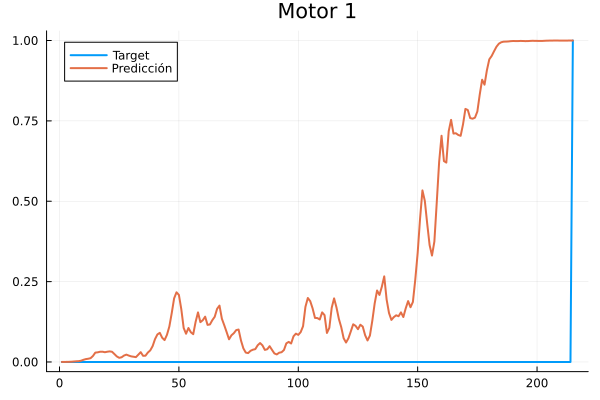

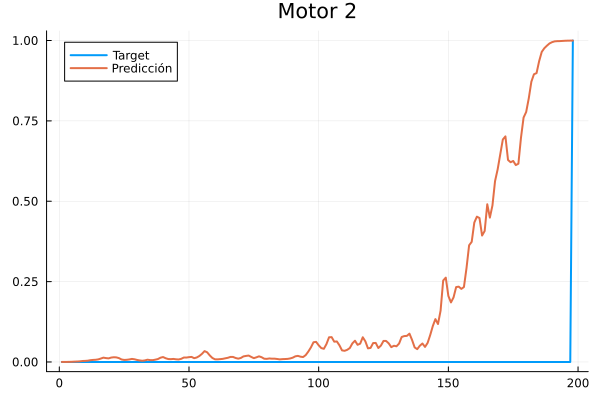

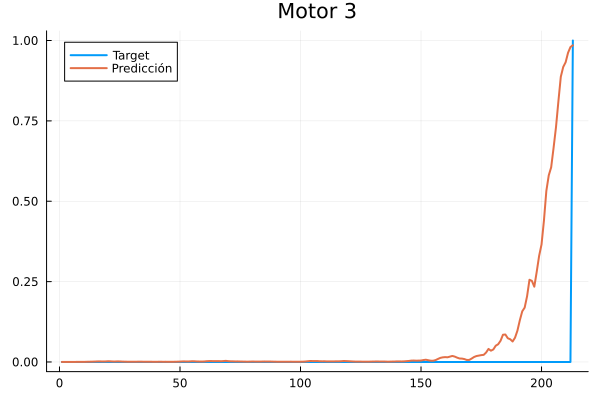

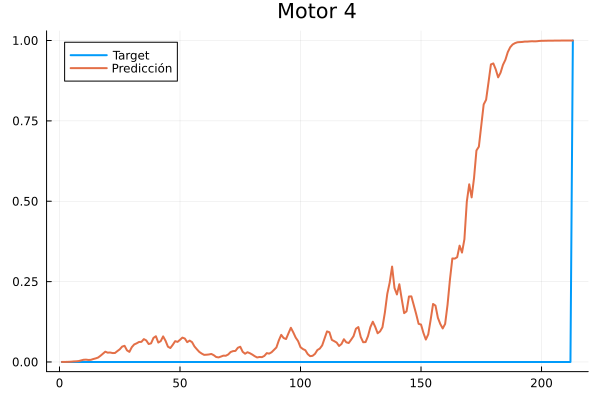

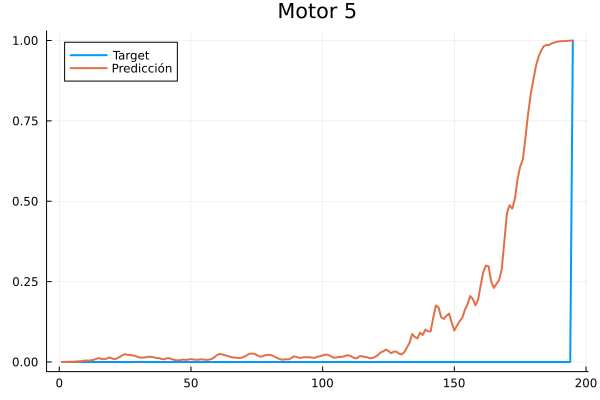

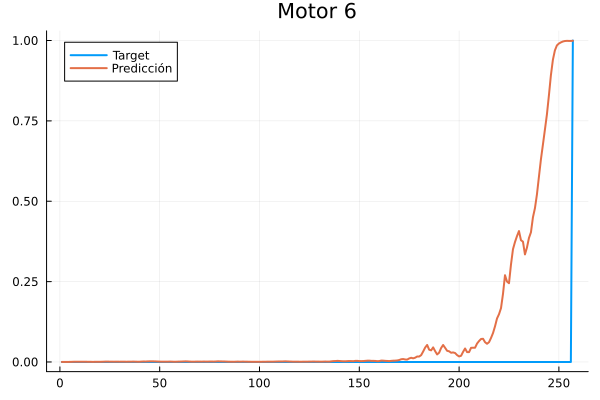

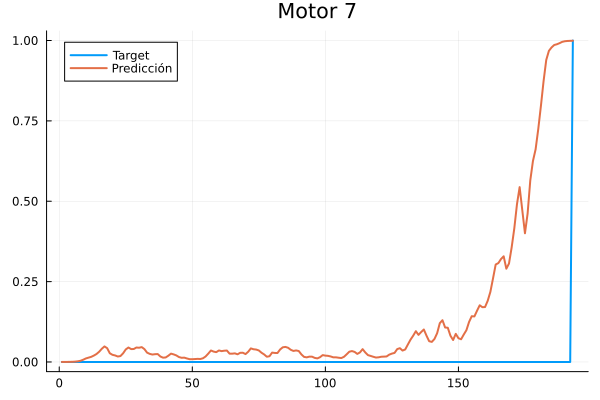

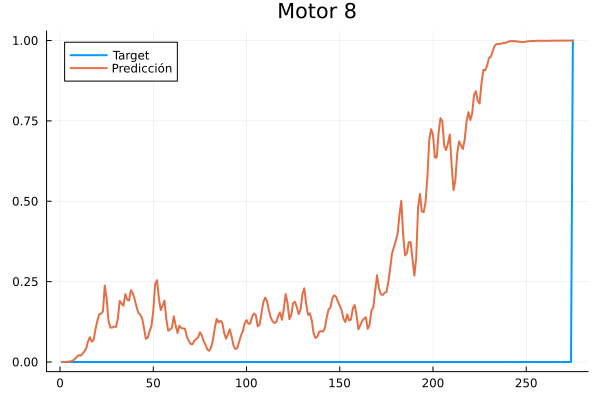

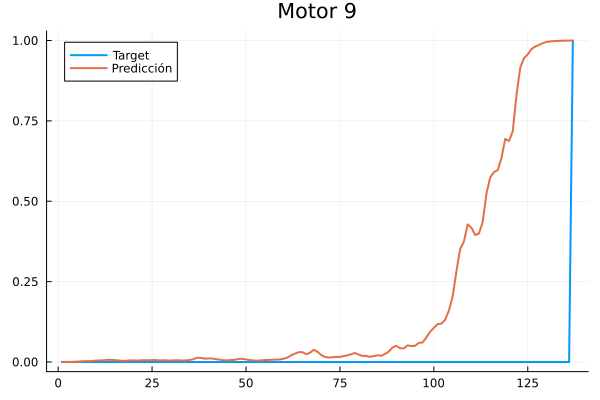

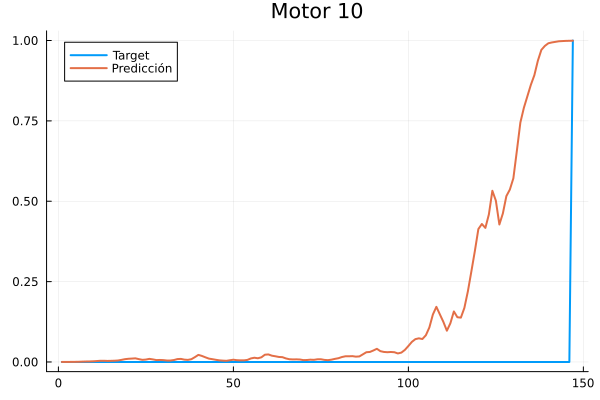

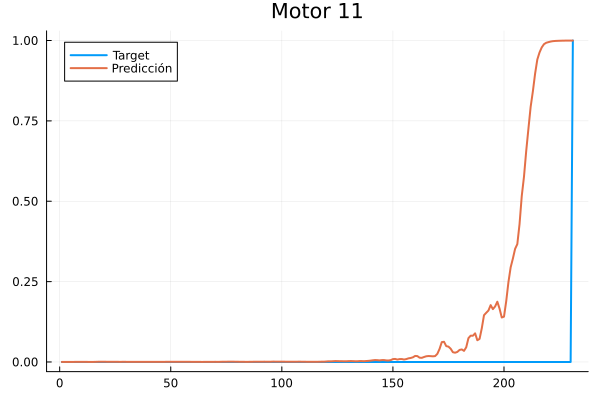

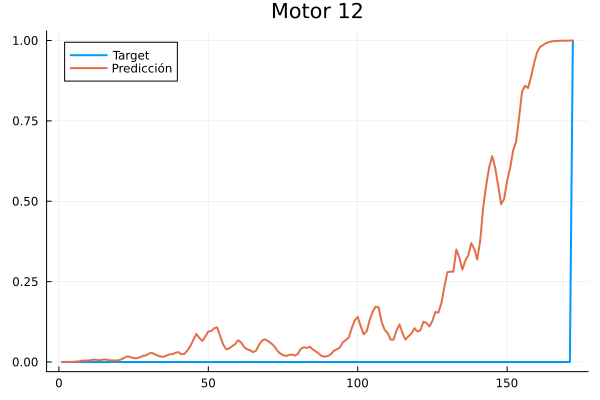

In [60]:
for (i, traj_plot) in enumerate(test_trajs)

    pred = predict_traj_sensors(
        p_trained_ude_sensors,
        traj_plot
    )

    p = plot(
        traj_plot.t,
        traj_plot.y,
        label = "Target",
        linewidth = 2,
        title = "Motor $i"
    )

    plot!(
        p,
        traj_plot.t,
        pred,
        label = "Predicción",
        linewidth = 2
    )

    display(p)

end

Mucho mejor las de horizonte

# tengo mucho sueño para pensar las otras, te pusheo para que veas (para pensar como armar el df y toda esa shie)

In [61]:
function failure_timing_df_gral(test_trajs, p_trained; threshold=0.5)

    results = DataFrame(
        motor = Int[],
        real_cycle = Union{Missing, Int}[],
        pred_cycle = Union{Missing, Int}[],
        diff_cycles = Union{Missing, Int}[]
    )

    for (i, traj) in enumerate(test_trajs)

        pred = predict_traj_sensors(p_trained, traj)

        # Caso exacto: y tiene un único 1 en el ciclo real de falla.
        idx_real = findfirst(==(1.0), traj.y)

        real_cycle =
            isnothing(idx_real) ? missing :
            Int(traj.t[idx_real])

        # Primer ciclo en el que la predicción supera el umbral.
        idx_pred = findfirst(x -> x >= threshold, pred)

        pred_cycle =
            isnothing(idx_pred) ? missing :
            Int(traj.t[idx_pred])

        diff =
            ismissing(real_cycle) || ismissing(pred_cycle) ?
            missing :
            pred_cycle - real_cycle

        push!(
            results,
            (
                i,
                real_cycle,
                pred_cycle,
                diff
            )
        )

    end

    return results

end

failure_timing_df_gral (generic function with 1 method)

In [62]:
function compute_metrics(df_eval)

    diffs = collect(skipmissing(df_eval.diff_cycles))

    n_total = nrow(df_eval)
    n_detected = length(diffs)
    n_missing = n_total - n_detected

    if isempty(diffs)
        return (
            mean_error = missing,
            median_error = missing,
            std_error = missing,
            mae = missing,
            rmse = missing,
            early_rate = missing,
            late_rate = missing,
            exact_rate = missing,
            detection_rate = 0.0,
            missing_rate = 1.0
        )
    end

    mean_error = mean(diffs)
    median_error = median(diffs)
    std_error = length(diffs) > 1 ? std(diffs) : 0.0

    mae = mean(abs.(diffs))
    rmse = sqrt(mean(diffs .^ 2))

    early_rate = mean(diffs .< 0)
    late_rate = mean(diffs .> 0)
    exact_rate = mean(diffs .== 0)

    detection_rate = n_detected / n_total
    missing_rate = n_missing / n_total

    return (
        mean_error = mean_error,
        median_error = median_error,
        std_error = std_error,
        mae = mae,
        rmse = rmse,
        early_rate = early_rate,
        late_rate = late_rate,
        exact_rate = exact_rate,
        detection_rate = detection_rate,
        missing_rate = missing_rate
    )

end

compute_metrics (generic function with 1 method)

In [63]:
results_df = DataFrame(
    model_name = String[],
    mean_error = Union{Missing, Float64}[],
    median_error = Union{Missing, Float64}[],
    std_error = Union{Missing, Float64}[],
    mae = Union{Missing, Float64}[],
    rmse = Union{Missing, Float64}[],
    early_rate = Union{Missing, Float64}[],
    late_rate = Union{Missing, Float64}[],
    exact_rate = Union{Missing, Float64}[],
    detection_rate = Float64[],
    missing_rate = Float64[]
)

Row,model_name,mean_error,median_error,std_error,mae,rmse,early_rate,late_rate,exact_rate,detection_rate,missing_rate
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64


In [64]:
function add_result!(results_df, model_name, df_eval)

    m = compute_metrics(df_eval)

    push!(
        results_df,
        (
            model_name,
            m.mean_error,
            m.median_error,
            m.std_error,
            m.mae,
            m.rmse,
            m.early_rate,
            m.late_rate,
            m.exact_rate,
            m.detection_rate,
            m.missing_rate
        )
    )

end

add_result! (generic function with 1 method)

In [65]:
df_eval = failure_timing_df_gral(
    test_trajs,
    p_trained_ude_sensors;
    threshold = 0.5
)

df_eval
add_result!(
    results_df,
    "UDE sensores exacto",
    df_eval
)

results_df

Row,model_name,mean_error,median_error,std_error,mae,rmse,early_rate,late_rate,exact_rate,detection_rate,missing_rate
,String,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64?,Float64,Float64
1,UDE sensores exacto,-33.0833,-23.0,22.9722,33.0833,39.7272,1.0,0.0,0.0,1.0,0.0


In [66]:
df_eval = failure_timing_df_gral(
    test_trajs,
    p_trained_ude_sensors;
    threshold=0.989
)

df_eval

Row,motor,real_cycle,pred_cycle,diff_cycles
,Int64,Int64?,Int64?,Int64?
1,1,215,184,-31
2,2,198,189,-9
3,3,213,missing,missing
4,4,213,189,-24
5,5,195,187,-8
6,6,257,250,-7
7,7,193,188,-5
8,8,275,235,-40
9,9,137,129,-8


### Que hice hasta aca:

+ NODE Y UDE sin sensores

+ UDE con sensores y peso en la loss

+ Seleccion de mejores sensores y UDE

+ Ajuste de pesos

+ Metodo Horizonte

+ hacer un entrenamiento grande

+ analisis de resultados

### Cosas que faltan de lo que teniamos antes:

+ probar distintos modelos y parametros entrenables

+ agregar a comparativa de resultados

### Cosas a considerar para esta nueva forma de plantear el problema

+ arreglar salts (horizonte y forma original) -- no me preocuparia por eso -- nO mE prEoCuParIa pOr eSo, boludo